In [13]:
# various import statements
import os
import inspect
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import torch
import scanpy as sc
import pyro
from collections import defaultdict
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import sys
import antipode
from antipode.antipode_model import *
import antipode.model_functions
from antipode.model_functions import *
import antipode.model_distributions
from antipode.model_distributions import *
import antipode.model_modules
from antipode.model_modules import *
import antipode.train_utils
from antipode.train_utils import *
import antipode.plotting
from antipode.plotting import *
from antipode.antipode_mixins import AntipodeTrainingMixin, AntipodeSaveLoadMixin


GPU is available
Number of GPUs: 1
GPU Name: NVIDIA A100-PCIE-40GB


In [317]:
import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan


def _compute_log_r(model_trace, guide_trace):
    log_r = MultiFrameTensor()
    stacks = get_plate_stacks(model_trace)
    for name, model_site in model_trace.nodes.items():
        if model_site["type"] == "sample":
            log_r_term = model_site["log_prob"]
            if not model_site["is_observed"]:
                log_r_term = log_r_term - guide_trace.nodes[name]["log_prob"]
            log_r.add((stacks[name], log_r_term.detach()))
    return log_r



class Print_Trace_ELBO(ELBO):
    """
    A trace implementation of ELBO-based SVI. The estimator is constructed
    along the lines of references [1] and [2]. There are no restrictions on the
    dependency structure of the model or the guide. The gradient estimator includes
    partial Rao-Blackwellization for reducing the variance of the estimator when
    non-reparameterizable random variables are present. The Rao-Blackwellization is
    partial in that it only uses conditional independence information that is marked
    by :class:`~pyro.plate` contexts. For more fine-grained Rao-Blackwellization,
    see :class:`~pyro.infer.tracegraph_elbo.TraceGraph_ELBO`.

    References

    [1] Automated Variational Inference in Probabilistic Programming,
        David Wingate, Theo Weber

    [2] Black Box Variational Inference,
        Rajesh Ranganath, Sean Gerrish, David M. Blei
    """

    def _get_trace(self, model, guide, args, kwargs):
        """
        Returns a single trace from the guide, and the model that is run
        against it.
        """
        model_trace, guide_trace = get_importance_trace(
            "flat", self.max_plate_nesting, model, guide, args, kwargs
        )
        if is_validation_enabled():
            check_if_enumerated(guide_trace)
        return model_trace, guide_trace

    def loss(self, model, guide, *args, **kwargs):
        """
        :returns: returns an estimate of the ELBO
        :rtype: float

        Evaluates the ELBO with an estimator that uses num_particles many samples/particles.
        """
        elbo = 0.0
        for model_trace, guide_trace in self._get_traces(model, guide, args, kwargs):
            elbo_particle = torch_item(model_trace.log_prob_sum()) - torch_item(
                guide_trace.log_prob_sum()
            )
            elbo += elbo_particle / self.num_particles

        loss = -elbo
        warn_if_nan(loss, "loss")
        return loss

    def _differentiable_loss_particle(self, model_trace, guide_trace):
        elbo_particle = 0
        surrogate_elbo_particle = 0
        log_r = None

        # compute elbo and surrogate elbo
        for name, site in model_trace.nodes.items():
            if site["type"] == "sample":
                print(name,site["log_prob_sum"])
                elbo_particle = elbo_particle + torch_item(site["log_prob_sum"])
                surrogate_elbo_particle = surrogate_elbo_particle + site["log_prob_sum"]

        for name, site in guide_trace.nodes.items():
            if site["type"] == "sample":
                log_prob, score_function_term, entropy_term = site["score_parts"]
                print(name,site["log_prob_sum"])
                elbo_particle = elbo_particle - torch_item(site["log_prob_sum"])

                if not is_identically_zero(entropy_term):
                    surrogate_elbo_particle = (
                        surrogate_elbo_particle - entropy_term.sum()
                    )

                if not is_identically_zero(score_function_term):
                    if log_r is None:
                        log_r = _compute_log_r(model_trace, guide_trace)
                    site = log_r.sum_to(site["cond_indep_stack"])
                    surrogate_elbo_particle = (
                        surrogate_elbo_particle + (site * score_function_term).sum()
                    )

        return -elbo_particle, -surrogate_elbo_particle

    def differentiable_loss(self, model, guide, *args, **kwargs):
        """
        Computes the surrogate loss that can be differentiated with autograd
        to produce gradient estimates for the model and guide parameters
        """
        loss = 0.0
        surrogate_loss = 0.0
        for model_trace, guide_trace in self._get_traces(model, guide, args, kwargs):
            loss_particle, surrogate_loss_particle = self._differentiable_loss_particle(
                model_trace, guide_trace
            )
            surrogate_loss += surrogate_loss_particle / self.num_particles
            loss += loss_particle / self.num_particles
        warn_if_nan(surrogate_loss, "loss")
        return loss + (surrogate_loss - torch_item(surrogate_loss))

    def loss_and_grads(self, model, guide, *args, **kwargs):
        """
        :returns: returns an estimate of the ELBO
        :rtype: float

        Computes the ELBO as well as the surrogate ELBO that is used to form the gradient estimator.
        Performs backward on the latter. Num_particle many samples are used to form the estimators.
        """
        loss = 0.0
        # grab a trace from the generator
        for model_trace, guide_trace in self._get_traces(model, guide, args, kwargs):
            loss_particle, surrogate_loss_particle = self._differentiable_loss_particle(
                model_trace, guide_trace
            )
            loss += loss_particle / self.num_particles

            # collect parameters to train from model and guide
            trainable_params = any(
                site["type"] == "param"
                for trace in (model_trace, guide_trace)
                for site in trace.nodes.values()
            )

            if trainable_params and getattr(
                surrogate_loss_particle, "requires_grad", False
            ):
                surrogate_loss_particle = surrogate_loss_particle / self.num_particles
                surrogate_loss_particle.backward(retain_graph=self.retain_graph)
        warn_if_nan(loss, "loss")
        return loss

In [356]:
grads=defaultdict(list)


class SafeSVI(TracePosterior):
    '''A version of pyro.infer.SVI that skips steps with loss more than X sigma from the running mean loss'''
    def __init__(
        self,
        model,
        guide,
        optim,
        loss,
        loss_and_grads=None,
        clip_std_multiplier=6.0,
        window_size=1000,  # Default window size of 300
        **kwargs
    ):
        super().__init__(**kwargs)
        self.model = model
        self.guide = guide
        self.optim = optim
        self.clip_std_multiplier = clip_std_multiplier
        self.window_size = window_size
        self.losses = []  # Store recent losses to calculate running stats

        if not isinstance(optim, pyro.optim.PyroOptim):
            raise ValueError("Optimizer should be an instance of pyro.optim.PyroOptim class.")

        if isinstance(loss, ELBO):
            self.loss = loss.loss
            self.loss_and_grads = loss.loss_and_grads
        else:
            if loss_and_grads is None:
                def _loss_and_grads(*args, **kwargs):
                    loss_val = loss(*args, **kwargs)
                    if getattr(loss_val, "requires_grad", False):
                        loss_val.backward(retain_graph=True)
                    return loss_val
                self.loss_and_grads = _loss_and_grads
            else:
                self.loss_and_grads = loss_and_grads

    def _traces(self, *args, **kwargs):
        for i in range(self.num_samples):
            guide_trace = poutine.trace(self.guide).get_trace(*args, **kwargs)
            model_trace = poutine.trace(
                poutine.replay(self.model, trace=guide_trace)
            ).get_trace(*args, **kwargs)
            yield model_trace, 1.0

    def evaluate_loss(self, *args, **kwargs):
        with torch.no_grad():
            loss = self.loss(self.model, self.guide, *args, **kwargs)
            return torch_item(loss)

    def step(self, *args, **kwargs):
        # Compute loss and gradients
        with poutine.trace(param_only=True) as param_capture:
            loss = self.loss_and_grads(self.model, self.guide, *args, **kwargs)
    
        loss_val = torch_item(loss)
        self.losses.append(loss_val)
        # Keep only the last `window_size` losses
        if len(self.losses) > self.window_size:
            self.losses.pop(0)
        # Extract params early to ensure they are defined for later use
        params = set(site["value"].unconstrained() for site in param_capture.trace.nodes.values())
        
        # Calculate running mean and std only if we have enough data
        if len(self.losses) >= self.window_size:
            running_mean = np.mean(self.losses)
            running_std = np.std(self.losses)
            #print(loss, running_mean,running_std)
            if ((loss > running_mean-running_std*self.clip_std_multiplier) and (loss < running_mean+running_std*self.clip_std_multiplier)):
                # Perform optimization step
                self.optim(params)
            else:
                print('STEP SKIPPED')
                #print(self.losses)
                #print(loss, running_mean,running_std*self.clip_std_multiplier)
                #seaborn.lineplot(self.losses)
                #plt.show()
                #seaborn.histplot(self.losses)
                #plt.show()
        else:
            self.optim(params)

        for name, value in pyro.get_param_store().named_parameters():
            grads[name].append(value.grad.detach().cpu().numpy())
        
        # Zero gradients
        pyro.infer.util.zero_grads(params)
    
        return loss_val

class AntipodeTrainingMixin:
    '''
    Mixin class providing functions to actually run ANTIPODE.
    The naive model trains in 3 phases, first a nonhierarchical block phase to estimate cell type manifolds, then phase 2 learns parameters for a fixed discrete clustering on a fixed latent space for initialization (or supervised). Phase 3 makes all parameters learnable.
    You can also use supervised taxonomy by providing a clustering as a discrete obsm matrix and training only phase2 with freeze_encoder=False.
    '''
    
    def save_params_to_uns(self,prefix=''):
        pstore=param_store_to_numpy()
        pstore={n:pstore[n] for n in pstore.keys() if not re.search('encoder|classifier|be_nn|\$\$\$',n)}
        pstore={n:pstore[n] for n in pstore.keys() if not np.isnan(pstore[n]).any()}
        self.adata_manager.adata.uns[prefix+'param_store']=pstore

    def get_antipode_outputs(self,batch_size=2048,device='cuda'):
        if 'discov_onehot' not in self.adata_manager.adata.obsm.keys():
            self.adata_manager.adata.obs[self.discov_key]=self.adata_manager.adata.obs[self.discov_key].astype('category')
            self.adata_manager.adata.obsm['discov_onehot']=numpy_onehot(self.adata_manager.adata.obs[self.discov_key].cat.codes)
        self.adata_manager.register_new_fields([scvi.data.fields.ObsmField('discov_onehot','discov_onehot')])
    
        field_types={"s":np.float32,"discov_onehot":np.float32}
        dataloader=scvi.dataloaders.AnnDataLoader(self.adata_manager,batch_size=32,drop_last=False,shuffle=False,data_and_attributes=field_types)#supervised_field_types for supervised step 
        encoder_outs=batch_output_from_dataloader(dataloader,self.zl_encoder,batch_size=batch_size,device=device)
        encoder_outs[0]=self.z_transform(encoder_outs[0])
        encoder_out=[x.detach().cpu().numpy() for x in encoder_outs]
        classifier_outs=batch_torch_outputs([(encoder_outs[0])],self.classifier,batch_size=batch_size,device='cuda')
        classifier_out=[x.detach().cpu().numpy() for x in classifier_outs]
        return encoder_out,classifier_out

    def store_outputs(self,device='cuda',prefix=''):
        self.save_params_to_uns(prefix='')
        self.to('cpu')
        self.eval()
        antipode_outs=self.get_antipode_outputs(batch_size=2048,device=device)
        self.allDone()
        taxon=antipode_outs[1][0]
        self.adata_manager.adata.obsm[prefix+'X_antipode']=antipode_outs[0][0]
        for i in range(antipode_outs[1][1].shape[1]):
            self.adata_manager.adata.obs[prefix+'psi_'+str(i)]=numpy_centered_sigmoid(antipode_outs[1][1][...,i])
        self.adata_manager.adata.obs[prefix+'q_score']=scipy.special.expit(antipode_outs[0][2])
        level_edges=[numpy_hardmax(self.adata_manager.adata.uns[prefix+'param_store']['edges_'+str(i)],axis=-1) for i in range(len(self.level_sizes)-1)]
        levels=self.tree_convergence_bottom_up.just_propagate(scipy.special.softmax(taxon[...,-self.level_sizes[-1]:],axis=-1),level_edges,s=torch.ones(1))
        prop_taxon=np.concatenate(levels,axis=-1)
        self.adata_manager.adata.obsm[prefix+'taxon_probs']=prop_taxon
        levels=self.tree_convergence_bottom_up.just_propagate(numpy_hardmax(levels[-1],axis=-1),level_edges,s=torch.ones(1))
        for i in range(len(levels)):
            cur_clust=prefix+'level_'+str(i)
            self.adata_manager.adata.obs[cur_clust]=levels[i].argmax(1)
            self.adata_manager.adata.obs[cur_clust]=self.adata_manager.adata.obs[cur_clust].astype(str)
        self.adata_manager.adata.obs[prefix+'antipode_cluster'] = self.adata_manager.adata.obs.apply(lambda x: '_'.join([x[prefix+'level_'+str(i)] for i in range(len(levels))]), axis=1)
        self.adata_manager.adata.obs[prefix+'antipode_cluster'] = self.adata_manager.adata.obs[prefix+'antipode_cluster'].astype(str)    
    
    def pretrain_classifier(self,epochs = 5,learning_rate = 0.001,batch_size = 64,prefix='',cluster='kmeans',device='cuda'):
        '''basic pytorch training of feed forward classifier to ease step 2'''        
        self.train()
        
        model = self.classifier.to(device)
        input_tensor =  torch.tensor(self.adata_manager.adata.obsm[self.dimension_reduction])  # Your input features tensor, shape [n_samples, n_features]
        target_tensor = torch.tensor(self.adata_manager.adata.obsm[cluster+'_onehot'])  # Your target labels tensor, shape [n_samples]    
        
        # Step 1: Prepare to train
        dataset = torch.utils.data.TensorDataset(input_tensor, target_tensor)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        
        #Training loop
        for epoch in range(epochs):
            for inputs, targets in dataloader:
                # Forward pass
                outputs = model(inputs.to(device))
                loss = criterion(softmax(outputs[0],-1)[:,-targets.shape[-1]:], targets.to(device))
        
                # Backward pass and optimize
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')     

    def fix_scale_factor(self,svi,x,ideal_val=0.1):
        o1=svi.evaluate_loss(*x)
        s1=self.scale_factor
        s2=ideal_val*s1/o1
        self.scale_factor=s2

    def prepare_phase_2(self,cluster='kmeans',prefix='',epochs = 5,device=None,dimension_reduction='X_antipode',reset_dc=True,naive_init=False):
        '''Run this if not running in supervised only mode (JUST phase2 with provided obsm clustering), 
        runs kmeans if cluster=kmeans, else uses the obs column provided by cluster. epochs=None skips pretraing of classifier
        To learn a latent space from scratch set dimension_reduction to None and use freeze_encoder=False'''
        if cluster=='kmeans':
            kmeans = sklearn.cluster.MiniBatchKMeans(n_clusters=self.level_sizes[-1],init='k-means++',max_iter=1000,reassignment_ratio=0.001,n_init=100,random_state=0).fit(self.adata_manager.adata.obsm[dimension_reduction])
            self.adata_manager.adata.obs['kmeans']=kmeans.labels_
            self.adata_manager.adata.obs['kmeans']=self.adata_manager.adata.obs['kmeans'].astype(int).astype('category')
            self.adata_manager.adata.obsm['kmeans_onehot']=numpy_onehot(self.adata_manager.adata.obs['kmeans'].cat.codes,num_classes=self.level_sizes[-1])
        else:
            self.adata_manager.adata.obs[cluster]=self.adata_manager.adata.obs[cluster].astype('category')
            self.adata_manager.adata.obsm[cluster+'_onehot']=numpy_onehot(self.adata_manager.adata.obs[cluster].cat.codes,num_classes=self.level_sizes[-1])
        device=pyro.param('locs').device if device is None else device
        self.adata_manager.register_new_fields([make_field('taxon',('obsm',cluster+'_onehot'))])
        if dimension_reduction is not None:#For supervised Z register dr
            self.dimension_reduction=dimension_reduction
            self.adata_manager.register_new_fields([make_field('Z_obs',('obsm',dimension_reduction))])
        if (epochs is not None) and (dimension_reduction is not None):
            self.pretrain_classifier(cluster=cluster,prefix=prefix,epochs=epochs,device=device)
        kmeans_means=group_aggr_anndata(self.adata_manager.adata,[cluster], agg_func=np.mean,layer=dimension_reduction,obsm=True)[0]
        if 'locs' not in [x for x in pyro.get_param_store()]:
            print('quick init')
            self.train_phase(phase=1,max_steps=1,print_every=10000,num_particles=1,device=device, max_learning_rate=1e-10, one_cycle_lr=True, steps=0, batch_size=4)
            self.cpu()
            
        if naive_init:
            new_locs=torch.concatenate(
                [pyro.param('locs').new_zeros(sum(self.level_sizes[:-1]),pyro.param('locs').shape[1]),
                 torch.tensor(kmeans_means-kmeans_means.mean(0),device=pyro.param('locs').device).float()],
                 axis=0).float()
            new_locs[0,:]=torch.tensor(kmeans_means.mean(0)).float()
        else:
            hierarchy=scipy.cluster.hierarchy.ward(kmeans_means)
            level_assignments=[scipy.cluster.hierarchy.cut_tree(hierarchy,n_clusters=x) for x in self.level_sizes]
            adj_means_dict=calculate_layered_tree_means(kmeans_means, level_assignments)
            new_clusts=[adj_means_dict[k][j] for k in adj_means_dict.keys() for j in adj_means_dict[k].keys()]
            new_locs=torch.tensor(new_clusts,device=device).float()
        
        edge_matrices=create_edge_matrices(level_assignments)
        edge_matrices=[torch.tensor(x,device=device) for x in edge_matrices]
        for i in range(len(self.level_sizes)-1):
            #pyro.get_param_store().__setitem__('edges_'+str(i), pyro.param('edges_'+str(i)).detach()+edge_matrices[i].T)
            pyro.get_param_store().__setitem__('edges_'+str(i), 1e-4 * torch.randn(edge_matrices[i].T.shape,device=device).float() + edge_matrices[i].T.float())
        
        self.adata_manager.adata.obs[cluster].astype(int)
        new_scales=group_aggr_anndata(self.adata_manager.adata,[cluster], agg_func=np.std,layer=dimension_reduction,obsm=True)[0]
        new_scales=torch.concatenate(
            [1e-5 * self.scale_init_val * new_locs.new_ones(sum(self.level_sizes[:-1]), pyro.param('locs').shape[1],requires_grad=True),
             torch.tensor(new_scales+1e-10,device=device,requires_grad=True)],axis=0).float()
        self.adata_manager.adata.obs[cluster].astype(str)
        pyro.get_param_store().__setitem__('locs',new_locs)
        pyro.get_param_store().__setitem__('locs_dynam',new_locs.new_zeros(new_locs.shape))
        pyro.get_param_store().__setitem__('scales',new_scales)
        self.adata_manager.adata.obs[cluster]=self.adata_manager.adata.obs[cluster].astype(str)
        pyro.get_param_store().__setitem__('discov_dm',new_locs.new_zeros(pyro.param('discov_dm').shape))
        pyro.get_param_store().__setitem__('seccov_dm',new_locs.new_zeros(pyro.param('seccov_dm').shape))
        pyro.get_param_store().__setitem__('batch_dm',new_locs.new_zeros(pyro.param('batch_dm').shape))
        pyro.get_param_store().__setitem__('discov_di',new_locs.new_zeros(pyro.param('discov_di').shape))
        pyro.get_param_store().__setitem__('batch_di',new_locs.new_zeros(pyro.param('batch_di').shape))
        pyro.get_param_store().__setitem__('cluster_intercept',new_locs.new_zeros(pyro.param('cluster_intercept').shape))
        if reset_dc: #DC doesn't necessarily need to be reset, can explode challenging models
            pyro.get_param_store().__setitem__('discov_dc',new_locs.new_zeros(pyro.param('discov_dc').shape))
    
    def common_training_loop(self, dataloader, max_steps, scheduler, svi, print_every, device, steps=0):
        self.losses = []
        pbar = tqdm.tqdm(total=max_steps, position=0)

        while steps < max_steps:
            for x in dataloader:
                x['step'] = torch.ones(1).to(device) * steps
                x = [x[k].squeeze(0).to(device) if k in x.keys() else torch.zeros(1) for k in self.args]
                if (self.scale_factor == 1.):
                    print('fix scale factor')
                    self.fix_scale_factor(svi, x)
                    gradient_norms = defaultdict(list)
                    for name, value in pyro.get_param_store().named_parameters():
                        value.register_hook(
                            lambda g, name=name: gradient_norms[name].append(g.grad)#.norm().item())
                        )
                pbar.update(1)
                loss = svi.step(*x)
                steps += 1
                if hasattr(scheduler, 'step'):
                    scheduler.step()
                if steps >= max_steps - 1 :
                    break
                
                self.losses.append(loss)
                if steps % print_every == 0:
                    pbar.write(f"[Step {steps:02d}]  Loss: {np.mean(self.losses[-print_every:]):.5f}")
        pbar.close()
        try:
            self.allDone()
        except:
            pass
        return(gradient_norms)

    def setup_scheduler(self, max_learning_rate, max_steps, one_cycle_lr):
        if one_cycle_lr:
            return pyro.optim.OneCycleLR({
                'max_lr': max_learning_rate,
                'total_steps': max_steps,
                'div_factor': 100,
                'optim_args': {},
                'optimizer': torch.optim.Adam
            })
        else:
            return pyro.optim.ClippedAdam({
                'lr': max_learning_rate,
                'lrd': (1 - (5e-6))
            })

    def train_phase(self, phase, max_steps, print_every=10000, device='cuda', max_learning_rate=0.001, num_particles=1, one_cycle_lr=True, steps=0, batch_size=32,freeze_encoder=None,print_elbo=False):
        self.scale_factor=1.
        freeze_encoder = True if freeze_encoder is None and phase == 2 else freeze_encoder
        freeze_encoder = False if freeze_encoder is None else  freeze_encoder
        self.set_freeze_encoder(freeze_encoder) 
        supervised_field_types=self.field_types.copy()
        supervised_fields=self.fields.copy()
        supervised_field_types["taxon"]=np.float32
        
        if not freeze_encoder and ("Z_obs" in [x.registry_key for x in  self.adata_manager.fields]) and phase == 2: #Running supervised D.R. (can't freeze encoder and run d.r.)
            supervised_field_types["Z_obs"]=np.float32
        field_types=self.field_types if phase != 2 else supervised_field_types
        sampler=create_weighted_random_sampler(self.adata_manager.adata.obs[self.sampler_category]) if self.sampler_category is not None else create_weighted_random_sampler(pd.Series(["same_category"] * self.adata_manager.adata.shape[0]))
        sampler= torch.utils.data.BatchSampler(sampler=sampler,batch_size=batch_size,drop_last=True)
        dataloader = scvi.dataloaders.AnnDataLoader(self.adata_manager, batch_size=batch_size, drop_last=True, sampler=sampler, data_and_attributes=field_types)
        scheduler = self.setup_scheduler(max_learning_rate, max_steps, one_cycle_lr)
        elbo_class = pyro.infer.JitTrace_ELBO if not print_elbo else Print_Trace_ELBO
        elbo = elbo_class(num_particles=num_particles, strict_enumeration_warning=False)
        hide_params=[name for name in pyro.get_param_store() if re.search('encoder',name)]
        guide=self.guide if not self.freeze_encoder else poutine.block(self.guide,hide=hide_params)
        svi = SafeSVI(self.model, guide, scheduler, elbo,clip_std_multiplier=6.0)  
        self.train()
        self.zl_encoder.eval() if self.freeze_encoder else self.zl_encoder.train()
        self = self.to(device)
        self.set_approx(phase == 1)
        return self.common_training_loop(dataloader, max_steps, scheduler, svi, print_every, device, steps)
        
    def allDone(self):
        print("Finished training!")
        self.to('cpu')
        try:
            import IPython
            from IPython.display import Audio, display
            IPython.display.clear_output()#Make compatible with jupyter nbconvert
            display(Audio(url='https://notification-sounds.com/soundsfiles/Meditation-bell-sound.mp3', autoplay=True))
        except:
            pass
    
    def clear_cuda(self):
        '''Throw the kitchen sink at clearing the cuda cache for jupyter notebooks. 
        Might want to wrap in tryexcept'''
        import traceback
        self.to('cpu')
        torch.cuda.empty_cache()
        gc.collect()
        try:
            a = 1/0 
        except Exception as e:  
            exc_type, exc_value, exc_traceback = sys.exc_info()
            traceback.clear_frames(exc_traceback)


class ANTIPODE(PyroBaseModuleClass,AntipodeTrainingMixin, AntipodeSaveLoadMixin):
    """
    ANTIPODE (Single Cell Ancestral Node Taxonomy Inference by Parcellation of Differential Expression) 
    leverages variational inference for analyzing and categorizing cell types by accounting for biological and batch covariates and discrete and continuous latent variables. This model works by simultaneously integrating evolution-inspired differential expression parcellation, taxonomy generation (clustering) and batch correction.

    Parameters:
    adata (AnnData): The single-cell dataset encapsulated in an AnnData object.
    discov_pair (tuple): Specifies the discovery covariate's key and its location ('obs' or 'obsm') in the AnnData object.
    batch_pair (tuple): Specifies the batch covariate's key and its location ('obs' or 'obsm') in the AnnData object.
    seccov_key (string):  Specifies the secondary covariate matrix's key in obsm in the AnnData object. Only affects DM.
    layer (str): The specific layer of the AnnData object to be analyzed.
    level_sizes (list of int): Defines the hierarchical model structure (corresponding to a layered tree) by specifying the size of each level. Make sure each layer gets progressively larger and ideally start with a single root. Defaults to [1, 10, 100].
    bi_depth (int): Tree depth (from root) for batch identity effect correction. Defaults to 2. Should be less than length of level_sizes
    psi_levels (list of bool): Whether or not to allow a psi at each level of the layered tree. Should be 1. (all levels) or a list of len(level_sizes)
    
    num_latent (int): The number of latent dimensions to model. Defaults to 50.
    num_batch_embed (int): Number of embedding dimensions for batch effects. Defaults to 10. 
    scale_factor (float, optional): Factor for scaling the data normalization. Inferred from data if None. [DANGER]
    prior_scale (float): Scale for the Laplace prior distributions. Defaults to 100. [DANGER]
    dcd_prior (float, optional): Scale for discov_constitutive_de. Use this for missing genes (set to large negative value and rest 0. Zeros if None.
    use_psi (bool): Whether to utilize psi continuous variation parameter. Defaults to True.
    use_q_score (bool): Whether to use q continuous "quality" scores. Defaults to True.
    dist_normalize (bool): EXPERIMENTAL. Whether to apply distance normalization. Defaults to False.
    z_transform (pytorch function): Function to be applied to latent space (Z) e.g. centered_sigmoid, sigmoid. This will mess up DE Parameter scaling.
    loc_as_param, zdw_as_param, intercept_as_param (bool): Flags for using location, Z decoder weight, and intercept as parameters instead (maximum likelihood inference instead of Laplace MAP), respectively. All default to False.
    theta_prior (float): Initial value for the inverse dispersion of the negative binomial. Defaults to 50. [DANGER]
    scale_init_val (float): Initial value for scaling parameters in phase 1. Defaults to 0.01. [DANGER]
    classifier_hidden, encoder_hidden, batch_embedder_hidden (list of int): Sizes of hidden layers for the classifier, encoder and batch embedding networks, respectively.
    sampler_category (string): Obs categorical column which will be used with the dataloader to sample each category with equal probability. (suggested use is the discov category)
    """

    def __init__(self, adata, discov_pair, batch_pair, layer, seccov_key='seccov_dummy', level_sizes=[1,10,100],
                 num_latent=50,scale_factor=None, prior_scale=100,dcd_prior=None,use_psi=True,sampler_category=None,
                 loc_as_param=True,zdw_as_param=True,intercept_as_param=True,seccov_as_param=True,use_q_score=True,psi_levels=[True],
                 num_batch_embed=10,theta_prior=50.,min_theta=1.,scale_init_val=0.01,bi_depth=2,dist_normalize=False,z_transform=None,
                 classifier_hidden=[3000,3000,3000],encoder_hidden=[6000,5000,3000,1000],batch_embedder_hidden=[1000,500,500]):

        pyro.clear_param_store()
        self.init_args = dict(locals())
        # Determine num_discov and num_batch from the AnnData object
        self.discov_loc, self.discov_key = discov_pair
        self.batch_loc, self.batch_key = batch_pair
        self.seccov_key=seccov_key
        self.num_discov = adata.obsm[self.discov_key].shape[-1] if self.discov_loc == 'obsm' else len(adata.obs[self.discov_key].unique())
        self.num_batch = adata.obsm[self.batch_key].shape[-1] if self.batch_loc == 'obsm' else len(adata.obs[self.batch_key].unique())        
        self.design_matrix = (self.discov_loc == 'obsm')
        self.layer = layer
        self.num_seccov = adata.obsm[self.seccov_key].shape[-1] if self.seccov_key != 'seccov_dummy' else 1
        
        self._setup_adata_manager_store: dict[str, type[scvi.data.AnnDataManager]] = {}
        self.num_var = adata.layers[layer].shape[-1]
        self.num_latent = num_latent
        self.scale_factor = 1.0#scale_factor if scale_factor is not None else 2e2 / (self.num_var * num_particles * num_latent)
        self.num_batch_embed = num_batch_embed
        self.temperature = 0.1
        self.epsilon = 1e-5
        self.approx = False
        self.prior_scale = prior_scale
        self.use_psi = use_psi
        self.use_q_score = use_q_score
        self.loc_as_param = loc_as_param
        self.zdw_as_param = zdw_as_param
        self.seccov_as_param = seccov_as_param
        self.intercept_as_param = intercept_as_param
        self.theta_prior = theta_prior
        self.scale_init_val = scale_init_val
        self.level_sizes = level_sizes
        self.num_labels = sum(level_sizes)
        self.bi_depth = bi_depth
        self.bi_depth = sum(self.level_sizes[:self.bi_depth])
        self.dist_normalize = dist_normalize
        self.sampler_category = sampler_category
        self.psi_levels = [float(x) for x in psi_levels]
        self.min_theta=min_theta
        
        self.dcd_prior = torch.zeros((self.num_discov,self.num_var)) if dcd_prior is None else dcd_prior#Use this for 
                
        # Initialize plates to be used during sampling
        self.var_plate = pyro.plate('var_plate',self.num_var,dim=-1)
        self.discov_plate = pyro.plate('discov_plate',self.num_discov,dim=-3)
        self.seccov_plate = pyro.plate('seccov_plate',self.num_seccov,dim=-3)
        self.batch_plate = pyro.plate('batch_plate',self.num_batch,dim=-3)
        self.latent_plate = pyro.plate('latent_plate',self.num_latent,dim=-1)
        self.latent_plate2 = pyro.plate('latent_plate2',self.num_latent,dim=-2)
        self.label_plate = pyro.plate('label_plate',self.num_labels,dim=-2)
        self.batch_embed_plate = pyro.plate('batch_embed_plate',self.num_batch_embed,dim=-3)
        self.bi_depth_plate = pyro.plate('bi_depth_plate',self.bi_depth,dim=-2)

        #Initialize MAP inference modules
        self.dm=MAPLaplaceModule(self,'discov_dm',[self.num_discov,self.num_labels,self.num_latent],[self.discov_plate,self.label_plate,self.latent_plate])
        self.sm=MAPLaplaceModule(self,'seccov_dm',[self.num_seccov,self.num_labels,self.num_latent],[self.seccov_plate,self.label_plate,self.latent_plate],param_only=self.seccov_as_param)
        self.bm=MAPLaplaceModule(self,'batch_dm',[self.num_batch,self.num_labels,self.num_latent],[self.batch_plate,self.label_plate,self.latent_plate])
        self.di=MAPLaplaceModule(self,'discov_di',[self.num_discov,self.num_labels,self.num_var],[self.discov_plate,self.label_plate,self.var_plate])
        self.bei=MAPLaplaceModule(self,'batch_di',[self.num_batch_embed,self.bi_depth,self.num_var],[self.batch_embed_plate,self.bi_depth_plate,self.var_plate])
        self.ci=MAPLaplaceModule(self,'cluster_intercept',[self.num_labels, self.num_var],[self.label_plate,self.var_plate],param_only=self.intercept_as_param)
        self.dc=MAPLaplaceModule(self,'discov_dc',[self.num_discov,self.num_latent,self.num_var],[self.discov_plate,self.latent_plate2,self.var_plate])
        self.zdw=MAPLaplaceModule(self,'z_decoder_weight',[self.num_latent,self.num_var],[self.latent_plate2,self.var_plate],init_val=((2/self.num_latent)*(torch.rand(self.num_latent,self.num_var)-0.5)),param_only=self.zdw_as_param)
        self.zl=MAPLaplaceModule(self,'locs',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],param_only=self.loc_as_param)
        self.zs=MAPHalfCauchyModule(self,'scales',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],init_val=self.scale_init_val*torch.ones(self.num_labels,self.num_latent),constraint=constraints.positive,param_only=False)
        self.zld=MAPLaplaceModule(self,'locs_dynam',[self.num_labels,self.num_latent],[self.label_plate,self.latent_plate],param_only=False)
        self.qg=MAPLaplaceModule(self,'quality_genes',[1,self.num_var],[self.var_plate],param_only=False)
        
        self.tree_edges = TreeEdges(self,straight_through=False)
        self.tree_convergence_bottom_up = TreeConvergenceBottomUp(self)        
        self.z_transform = null_function if z_transform is None else z_transform#centered_sigmoid#torch.special.expit

        if self.design_matrix:
            fields={'s':('layers',self.layer),
            'discov_ind':('obsm',self.discov_key),
            'batch_ind':('obsm',self.batch_key),
            'seccov':('obsm',self.seccov_key)}
            field_types={"s":np.float32,"batch_ind":np.float32,"discov_ind":np.float32,'seccov':np.float32}
        else:
            fields={'s':('layers',self.layer),
            'discov_ind':('obs',self.discov_key),
            'batch_ind':('obs',self.batch_key),
            'seccov':('obsm',self.seccov_key)}
            field_types={"s":np.float32,"batch_ind":np.int64,"discov_ind":np.int64,'seccov':np.float32}

        self.fields=fields
        self.field_types=field_types
        self.setup_anndata(adata, {'discov_ind': discov_pair, 'batch_ind': batch_pair,'seccov':self.seccov_key}, self.field_types)
        
        super().__init__()
        # Setup the various neural networks used in the model and guide
        self.z_decoder=ZDecoder(num_latent=self.num_latent, num_var=self.num_var)        
        self.zl_encoder=ZLEncoder(num_var=self.num_var,hidden_dims=encoder_hidden,num_cat_input=self.num_discov,
                    outputs=[(self.num_latent,None),(self.num_latent,softplus),(1,None),(1,softplus)])
        
        self.classifier=Classifier(num_latent=self.num_latent,hidden_dims=classifier_hidden,
                    outputs=[(self.num_labels,None),(len(self.level_sizes),None),(len(self.level_sizes),softplus)])

        #Too large to exactly model gene-level batch effects for all cluster x batch
        self.be_nn=SimpleFFNN(in_dim=self.num_batch,hidden_dims=batch_embedder_hidden,
                    out_dim=self.num_batch_embed)
        
        self.epsilon = 0.006
        #Initialize model not in fuzzy mode
        self.approx=False
        self.prior_scale=prior_scale
        self.args=inspect.getfullargspec(self.model).args[1:]#skip self

    def setup_anndata(self,adata: anndata.AnnData,fields,field_types,**kwargs,):
        if self.seccov_key == 'seccov_dummy':
            adata.obsm['seccov_dummy']=np.zeros([adata.shape[0],1],dtype=np.int8)
        anndata_fields=[make_field(x,self.fields[x]) for x in self.fields.keys()]
            
        adata_manager = scvi.data.AnnDataManager(
            fields=anndata_fields
        )
        adata_manager.register_fields(adata, **kwargs)
        self.register_manager(adata_manager)
        if fields['discov_ind'][0]=='obsm':
            self.design_matrix=True
            if fields['batch_ind'][0]!='obsm':
                raise Exception("If discov is design matrix, batch must be as well!")

    def register_manager(self, adata_manager: scvi.data.AnnDataManager):
        adata_id = adata_manager.adata_uuid
        self._setup_adata_manager_store[adata_id] = adata_manager
        self.adata_manager=adata_manager
    
    def set_approx(self,b: bool):
        self.approx=b

    def set_freeze_encoder(self,b: bool):
        self.freeze_encoder=b

    # the generative model
    def model(self, s,discov_ind=torch.zeros(1),batch_ind=torch.zeros(1),seccov=torch.zeros(1),step=torch.ones(1),taxon=torch.zeros(1),Z_obs=torch.zeros(1)):
        # Register various nn.Modules (i.e. the decoder/encoder networks) with Pyro
        pyro.module("antipode", self)

        if not self.design_matrix:
            batch=index_to_onehot(batch_ind,[s.shape[0],self.num_batch]).to(s.device)
            discov=index_to_onehot(discov_ind,[s.shape[0],self.num_discov]).to(s.device)
            batch_ind=batch_ind.squeeze()
            discov_ind=discov_ind.squeeze()
        else:
            batch=batch_ind
            discov=discov_ind
        
        minibatch_plate=pyro.plate("minibatch_plate", s.shape[0],dim=-1)
        minibatch_plate2=pyro.plate("minibatch_plate2", s.shape[0],dim=-2)
        l = s.sum(1).unsqueeze(-1)
                
        # Scale all sample statements for numerical stability
        with poutine.scale(scale=self.scale_factor):
            # Counts parameter of NB (variance of the observation distribution)
            s_theta = pyro.param("s_inverse_dispersion", self.theta_prior * s.new_ones(self.num_var),
                               constraint=constraints.positive)
            
            #Weak overall histogram normalization
            discov_mul = pyro.param("discov_mul", s.new_ones(self.num_discov,1),constraint=constraints.positive) if self.dist_normalize else s.new_ones(self.num_discov,1)
            cur_discov_mul = torch.einsum('do,bd->bo',discov_mul, discov_ind) if self.design_matrix else discov_mul[discov_ind]
            
            dcd=pyro.param("discov_constitutive_de", self.dcd_prior.to(s.device))
            level_edges=self.tree_edges.model_sample(s,approx=self.approx)
            quality_genes=self.qg.model_sample(s) if self.use_q_score else 0.
            
            with minibatch_plate:
                batch_embed=centered_sigmoid(pyro.sample('batch_embed', dist.Laplace(s.new_zeros(self.num_batch_embed),
                                self.prior_scale*s.new_ones(self.num_batch_embed),validate_args=True).to_event(1)))
                beta_prior_a=1.*s.new_ones(self.num_labels)
                beta_prior_a[0]=10. #0 block is consititutive
                if self.approx:#Bernoulli blocks approx?
                    taxon_probs = pyro.sample("taxon_probs", dist.Beta(beta_prior_a,s.new_ones(self.num_labels),validate_args=True).to_event(1))
                    taxon = pyro.sample('taxon',dist.RelaxedBernoulli(temperature=0.1*s.new_ones(1),probs=taxon_probs).to_event(1))
                else:
                    taxon_probs=pyro.sample('taxon_probs',dist.Dirichlet(s.new_ones(s.shape[0],self.level_sizes[-1]),validate_args=True))
                    if sum(taxon.shape) > 1:#Supervised?
                        if taxon.shape[-1]==self.num_labels:#Totally supervised?
                            pass
                        else:#Only bottom layer is supervised?
                            taxon = taxon_probs = pyro.sample("taxon", dist.OneHotCategorical(probs=taxon_probs,validate_args=True),obs=taxon)
                            taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                            taxon = torch.concat(taxon,-1)
                    else:#Unsupervised
                        taxon = pyro.sample("taxon", 
                                         model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*s.new_ones(1),probs=taxon_probs,validate_args=True))                    
                        taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                        taxon = torch.concat(taxon,-1)
                    taxon_probs=self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s)
                    taxon_probs=torch.cat(taxon_probs,-1)
                   
            locs=self.zl.model_sample(s,scale=fest([taxon_probs],-1))
            scales=self.zs.model_sample(s,scale=fest([taxon_probs],-1))
            locs_dynam=self.zld.model_sample(s,scale=fest([taxon_probs],-1))
            discov_dm=self.dm.model_sample(s,scale=fest([discov,taxon_probs],-1))
            seccov_dm=self.sm.model_sample(s,scale=fest([seccov.abs()+1e-10,taxon_probs],-1))
            discov_di=self.di.model_sample(s,scale=fest([discov,taxon_probs],-1))
            batch_dm=self.bm.model_sample(s,scale=fest([batch,taxon_probs],-1))
            
            bei=self.bei.model_sample(s,scale=fest([batch_embed.abs(),taxon_probs[...,:self.bi_depth]],-1))
            cluster_intercept=self.ci.model_sample(s,scale=fest([taxon_probs],-1))
            
            with minibatch_plate:
                bi=torch.einsum('...bi,...ijk->...bjk',batch_embed,bei)
                bi=torch.einsum('...bj,...bjk->...bk',taxon[...,:self.bi_depth],bi)
                psi = centered_sigmoid(pyro.sample('psi',dist.Laplace(s.new_zeros(s.shape[0],len(self.level_sizes)),self.prior_scale*s.new_ones(s.shape[0],len(self.level_sizes))).to_event(1)))
                psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
                psi = 0 if not self.use_psi or self.approx else torch.repeat_interleave(psi, torch.tensor(self.level_sizes).to(s.device), dim=1)
                q = torch.sigmoid(pyro.sample('q',dist.Logistic(s.new_zeros(s.shape[0],1),s.new_ones(s.shape[0],1)).to_event(1))) if self.use_q_score else 1.0
                this_locs=oh_index(locs,taxon)
                this_scales=oh_index(scales,taxon)
                z=pyro.sample('z_loc',dist.Laplace(this_locs,0.5*self.prior_scale*s.new_ones(s.shape[0],self.num_latent),validate_args=True).to_event(1))
                z_dist=dist.Normal(this_locs,this_scales+self.epsilon,validate_args=True).to_event(1)
                if sum(Z_obs.shape) <=1: 
                     z=pyro.sample('z', z_dist) 
                else: #Supervised latent space
                    z=pyro.sample('z', z_dist)
                    z=pyro.sample('z_obs', dist.Normal(z,this_scales+self.epsilon,validate_args=True).to_event(1),obs=Z_obs)

            cur_discov_dm = oh_index1(discov_dm, discov_ind) if self.design_matrix else discov_dm[discov_ind]
            cur_batch_dm = oh_index1(batch_dm, batch_ind) if self.design_matrix else batch_dm[batch_ind]
            cur_dcd = oh_index(dcd, discov) if self.design_matrix else  dcd[discov_ind]
            cur_seccov_dm=oh_index1(seccov_dm,seccov)
                 
            z=z+oh_index2(cur_discov_dm,taxon) + oh_index2(cur_seccov_dm,taxon) + oh_index2(cur_batch_dm,taxon)+(oh_index(locs_dynam,taxon*psi))
            z=self.z_transform(z)                
            pseudo_z=oh_index(locs,taxon_probs)+oh_index2(cur_discov_dm,taxon_probs)+ oh_index2(cur_seccov_dm,taxon_probs) + oh_index2(cur_batch_dm,taxon_probs)+(oh_index(locs_dynam,taxon_probs*psi))
            pseudo_z=self.z_transform(pseudo_z)
            z_decoder_weight=self.zdw.model_sample(s,scale=fest([pseudo_z.abs()],-1))
            discov_dc=self.dc.model_sample(s,scale=fest([discov,pseudo_z.abs()],-1))
            cur_discov_di = oh_index1(discov_di, discov_ind) if self.design_matrix else discov_di[discov_ind]
            cur_discov_dc = oh_index1(discov_dc, discov_ind) if self.design_matrix else discov_dc[discov_ind]
            cur_discov_di=oh_index2(cur_discov_di,taxon)
            cur_cluster_intercept=oh_index(cluster_intercept,taxon) if not self.approx else 0.
            
            mu=torch.einsum('...bi,...bij->...bj',z,z_decoder_weight+cur_discov_dc)#+bc
            spliced_mu=mu+cur_dcd+cur_discov_di+cur_cluster_intercept+bi+((1-q)*quality_genes)
            norm_spliced_mu=spliced_mu*cur_discov_mul
            softmax_shift=pyro.param('softmax_shift',norm_spliced_mu.exp().sum(-1).mean().log())
            log_mu = l.log() + norm_spliced_mu - softmax_shift
            s_theta = (s_theta * q) + self.min_theta
            logits=log_mu-s_theta.log()
                      
            with minibatch_plate2:
                with self.var_plate,poutine.scale(scale=torch.tensor(var_scaling_factors).to(s.device)):
                    s_dist = dist.NegativeBinomial(total_count=s_theta + 0.1,logits=logits,validate_args=False)
                    s_out=pyro.sample("s", s_dist, obs=s.int())
                    log_probs=(s_dist.log_prob(s)*torch.tensor(var_scaling_factors,device=s.device)).mean(0).cpu().detach().numpy().flatten()
                    var_probs=(s_dist.log_prob(s)*torch.tensor(var_scaling_factors,device=s.device)).var(0).cpu().detach().numpy().flatten()
                    # b_dist = dist.Bernoulli(probs=(torch.sigmoid(logits)+torch.finfo(torch.float32).tiny)**s_theta)#p(0)=(1-p)**r
                    # b_out=pyro.sample("b",b_dist, obs=(s>0.).float())
                    #print((s_theta*(1-torch.sigmoid(logits)))/(torch.sigmoid(logits)**2))
                    # s_dist = dist.Normal(loc=log_mu.exp(), scale=((s_theta*(1-torch.sigmoid(logits)))/(torch.sigmoid(logits)**2))**.1 ,validate_args=False)
                    # s_out=pyro.sample("s", s_dist, obs=s.float())
                    seaborn.scatterplot(x=gene_means,y=log_probs,s=0.1)
                    plt.show()
                    seaborn.scatterplot(x=gene_means,y=np.log(var_probs),s=0.1)
                    plt.title('var')
                    plt.show()
                
            return(log_mu)
    
    # the variational distribution
    def guide(self, s,discov_ind=torch.zeros(1),batch_ind=torch.zeros(1),seccov=torch.zeros(1),step=torch.ones(1),taxon=torch.zeros(1),Z_obs=torch.zeros(1)):
        pyro.module("antipode", self)
        
        if not self.design_matrix:
            batch=index_to_onehot(batch_ind,[s.shape[0],self.num_batch]).to(s.device)
            discov=index_to_onehot(discov_ind,[s.shape[0],self.num_discov]).to(s.device)
            batch_ind=batch_ind.squeeze()
            discov_ind=discov_ind.squeeze()
        else:
            batch=batch_ind
            discov=discov_ind
        
        minibatch_plate=pyro.plate("minibatch_plate", s.shape[0])
        
        with poutine.scale(scale=self.scale_factor):
            level_edges=self.tree_edges.guide_sample(s,approx=self.approx) 
            with minibatch_plate:
                batch_embed=self.be_nn(batch)
                batch_embed=centered_sigmoid(pyro.sample('batch_embed', dist.Delta(batch_embed,validate_args=True).to_event(1)))
                if self.freeze_encoder:
                    with torch.no_grad():
                        z_loc, z_scale , q_loc,q_scale= self.zl_encoder(s,discov)
                        z_loc=z_loc.detach()
                        z_scale=z_scale.detach()
                        q_loc=q_loc.detach()
                        q_scale=q_scale.detach()
                else:
                    z_loc, z_scale, q_loc,q_scale= self.zl_encoder(s,discov)
                z=pyro.sample('z',dist.Normal(z_loc,z_scale+self.epsilon).to_event(1))
                q=pyro.sample('q',dist.Normal(q_loc,q_scale+self.epsilon).to_event(1))
                pyro.sample('z_loc',dist.Delta(z_loc).to_event(1))
                z=self.z_transform(z)
                taxon_logits,psi_loc,psi_scale=self.classifier(z)
                psi=centered_sigmoid(pyro.sample('psi',dist.Normal(psi_loc,psi_scale+self.epsilon).to_event(1)))
                psi=psi*torch.tensor(self.psi_levels).to(s.device).unsqueeze(0)
                psi = 0 if not self.use_psi or self.approx else torch.repeat_interleave(psi, torch.tensor(self.level_sizes).to(s.device), dim=1)
                if self.approx:
                    taxon_dist = dist.Delta(safe_sigmoid(taxon_logits),validate_args=True).to_event(1)
                    taxon_probs = pyro.sample("taxon_probs", taxon_dist)
                    taxon = pyro.sample('taxon',dist.RelaxedBernoulli(temperature=self.temperature*s.new_ones(1),probs=taxon_probs).to_event(1))
                else:
                    taxon_probs=pyro.sample('taxon_probs',dist.Delta(safe_softmax(taxon_logits[...,-self.level_sizes[-1]:],eps=1e-5)).to_event(1))
                    if sum(taxon.shape) > 1:
                        pass
                    else:
                        taxon = pyro.sample("taxon", model_distributions.SafeAndRelaxedOneHotCategorical(temperature=self.temperature*s.new_ones(1), probs=taxon_probs,validate_args=True))                    
                    if taxon.shape[-1]<self.num_labels:
                        taxon = self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon,level_edges,s)
                        taxon = torch.concat(taxon,-1)
                    taxon_probs=self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s) if self.freeze_encoder else self.tree_convergence_bottom_up.just_propagate(taxon_probs[...,-self.level_sizes[-1]:],level_edges,s)
                    taxon_probs=torch.cat(taxon_probs,-1)

            quality_genes=self.qg.guide_sample(s) if self.use_q_score else 0.
            locs=self.zl.guide_sample(s,scale=fest([taxon_probs],-1))
            scales=self.zs.guide_sample(s,scale=fest([taxon_probs],-1))
            locs_dynam=self.zld.guide_sample(s,scale=fest([taxon_probs],-1))
            discov_dm=self.dm.guide_sample(s,scale=fest([discov,taxon_probs],-1))
            seccov_dm=self.sm.guide_sample(s,scale=fest([seccov.abs()+1e-10,taxon_probs],-1))
            batch_dm=self.bm.guide_sample(s,scale=fest([batch,taxon_probs],-1))
            discov_di=self.di.guide_sample(s,scale=fest([discov,taxon_probs],-1))
            cluster_intercept=self.ci.guide_sample(s,scale=fest([taxon_probs],-1))
            bei=self.bei.guide_sample(s,scale=fest([batch_embed.abs(),taxon_probs[...,:self.bi_depth]],-1))#maybe should be abs sum bei
            cur_discov_dm = oh_index1(discov_dm, discov_ind) if self.design_matrix else discov_dm[discov_ind]
            cur_batch_dm = oh_index1(batch_dm, batch_ind) if self.design_matrix else batch_dm[batch_ind]
            cur_seccov_dm=oh_index1(seccov_dm,seccov)
            
            z=oh_index(locs,taxon)+oh_index2(cur_discov_dm,taxon)+oh_index2(cur_seccov_dm,taxon) + oh_index2(cur_batch_dm,taxon)+(oh_index(locs_dynam,taxon*psi))
            z=self.z_transform(z)
            pseudo_z=oh_index(locs,taxon_probs)+oh_index2(cur_discov_dm,taxon_probs)+oh_index2(cur_seccov_dm,taxon_probs) + oh_index2(cur_batch_dm,taxon_probs)+(oh_index(locs_dynam,taxon_probs*psi))
            pseudo_z=self.z_transform(pseudo_z)
            z_decoder_weight=self.zdw.guide_sample(s,scale=fest([pseudo_z.abs()],-1))
            discov_dc=self.dc.guide_sample(s,scale=fest([discov,pseudo_z.abs()],-1))

In [357]:
model_tag='1.9.1.8.3_Dev-Free-SecCovLaplace-NoSoftmax'#Laplace

In [358]:
batch_size=32
steps=0
max_steps=100000
num_particles=1
print_every=5000

# antipode_model=ANTIPODE.load(os.path.join('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/models',model_tag),prefix='p3_',device=device)
# adata=antipode_model.adata_manager.adata
# aggr_means=antipode.model_functions.group_aggr_anndata(adata,['species'],layer='spliced',normalize=True)
log_real_means=np.log(aggr_means[0]+1e-9) # #species,#cluster,#genes array
antipode_model=ANTIPODE.load(os.path.join('/allen/programs/celltypes/workgroups/rnaseqanalysis/EvoGen/Team/Matthew/models',model_tag),prefix='p3_',adata=adata,device=device)


INFO     Generating sequential column names                                                                        


In [359]:
gene_means=log_real_means.mean(0).mean(0)
var_scaling_factors = (np.quantile(np.exp(gene_means),.99)**1.)/(np.exp(gene_means)**1.)
var_scaling_factors = (var_scaling_factors.shape[-1]*var_scaling_factors/var_scaling_factors.sum())
#var_scaling_factors = -gene_means + gene_means.max() + 1


In [360]:
antipode_model.train()

gradient_norms=antipode_model.train_phase(phase=3,max_steps=5,print_every=10000,num_particles=1,device=device, max_learning_rate=1e-3, one_cycle_lr=True, steps=0, batch_size=32,print_elbo=True)

In [361]:
zdw_grads=np.absolute(np.stack(grads['z_decoder_weight'])).mean(0)

<Axes: >

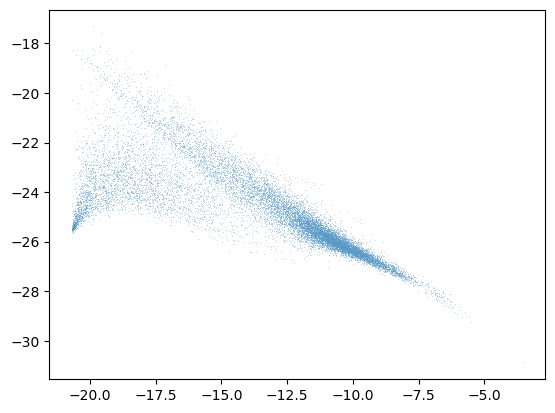

In [362]:
seaborn.scatterplot(x=log_real_means.mean(0).mean(0),y=np.log(zdw_grads.mean(0)),s=0.2)

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

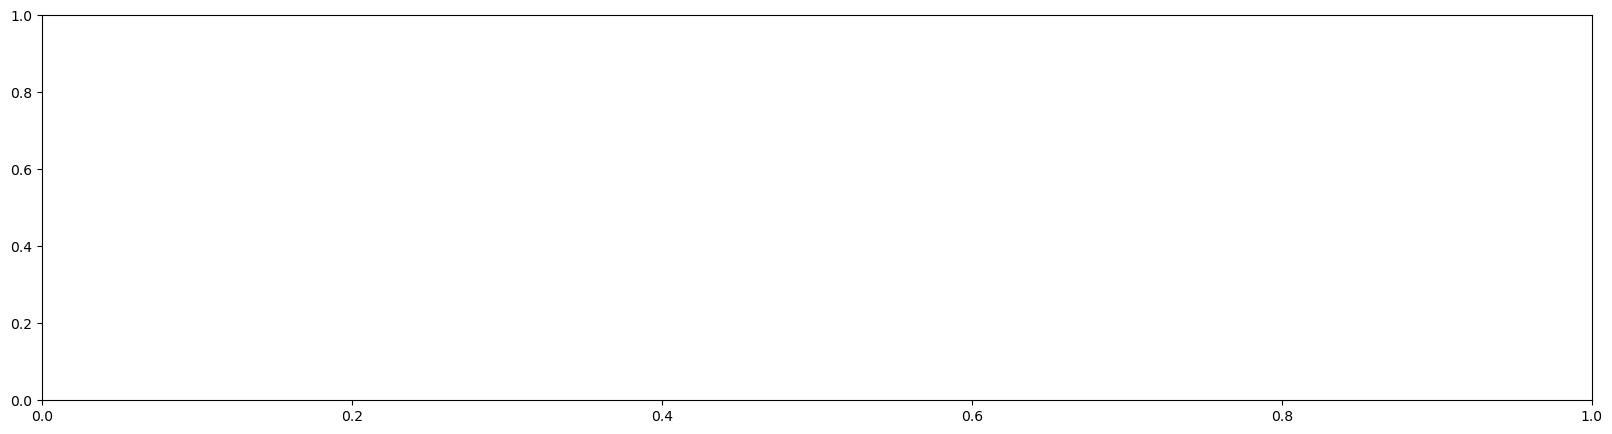

In [299]:
plt.figure(figsize=(20, 5), dpi=100).set_facecolor("white")
ax = plt.subplot(111)

w=50

for i,(name, grad_norms) in enumerate(gradient_norms.items()):
    if "$$" in name:
        continue
    mvavg=moving_average(np.pad(grad_norms,int(w/2),mode='edge'),w)
    seaborn.lineplot(x=list(range(len(mvavg))),y=mvavg,label=name,color=sc.pl.palettes.godsnot_102[i%102],ax=ax,linewidth = 1.)
    #seaborn.lineplot(grad_norms, label=name,color=sc.pl.palettes.godsnot_102[i%102],ax=ax,linewidth = 0.5)
    #seaborn.scatterplot(x=list(range(len(grad_norms))),y=grad_norms, label=name,color=sc.pl.palettes.godsnot_102[i%102],ax=ax,markers='o')
plt.xlabel("iters")
plt.ylabel("gradient norm")
plt.yscale("log")
#plt.legend(loc="best")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Gradient norms during SVI");


In [ ]:
log_mu=7.*torch.ones(1)
s_theta=2.*torch.ones(1)
logits=log_mu-s_theta.log()
print(dist.NegativeBinomial(total_count=s_theta,logits=logits).log_prob(torch.zeros(1)).exp())
print(dist.Bernoulli(probs=1-((s_theta * torch.nn.functional.logsigmoid(-logits))).exp()).log_prob(torch.zeros(1)).exp())
print(dist.Bernoulli(probs=(torch.sigmoid(logits)+torch.finfo(torch.float32).tiny)**s_theta).log_prob(torch.zeros(1)).exp())

In [ ]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_tree_edge_weights(antipode_model)

In [ ]:
pyro.param('softmax_shift')

In [ ]:
antipode_model.store_outputs(device=device,prefix='')

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
!nvidia-smi
antipode_model.clear_cuda()
!nvidia-smi

In [ ]:
plot_loss(antipode_model.losses)
plot_gmm_heatmaps(antipode_model)
plot_d_hists(antipode_model)
plot_batch_embedding_pca(antipode_model)

In [ ]:
prefix=''
pstore=adata.uns['param_store']
n_clusters=antipode_model.level_sizes[-1]
level_edges=[antipode.model_functions.numpy_hardmax(antipode_model.adata_manager.adata.uns[prefix+'param_store']['edges_'+str(i)],axis=-1) for i in range(len(antipode_model.level_sizes)-1)]
levels=antipode_model.tree_convergence_bottom_up.just_propagate(np.eye(antipode_model.level_sizes[-1]),level_edges)
prop_taxon=np.concatenate(levels,axis=-1)

discov_labels=adata.obs[antipode_model.discov_key].cat.categories
latent_labels=[str(x) for x in range(pstore['discov_dc'].shape[1])]
adata.obs['level_2']=adata.obs['level_2'].astype('category')
cluster_index=adata.obs['level_2'].cat.categories.astype(int)#list(range(antipode_model.level_sizes[-1]))#list(range(pstore['locs'].shape[0]))
cluster_labels=list(adata.obs['level_2'].cat.categories)
cluster_label_dict=dict(zip(cluster_index,cluster_labels))
var_labels=adata.var.index

prop_locs=prop_taxon@pstore['locs']
prop_cluster_intercept=prop_taxon@pstore['cluster_intercept']
cluster_params=(prop_locs@pstore['z_decoder_weight'])+prop_cluster_intercept+np.mean(pstore['discov_constitutive_de'],0,keepdims=True)
cluster_params=cluster_params[cluster_index,:]

#Need to propagate multilayer tree to discovs
prop_discov_di = np.einsum('pc,dcg->dpg',prop_taxon,pstore['discov_di'])
prop_discov_dm = np.einsum('pc,dcm->dpm',prop_taxon,pstore['discov_dm'])
discov_cluster_params=np.einsum('dpm,dmg->dpg',prop_locs+prop_discov_dm,pstore['z_decoder_weight']+pstore['discov_dc'])+(prop_cluster_intercept+prop_discov_di+np.expand_dims(pstore['discov_constitutive_de'],1))
discov_cluster_params=discov_cluster_params

In [ ]:
real_means=pd.DataFrame(log_real_means.mean(0),columns=adata.var.index,index=aggr_means[1]['level_2'])
real_means=real_means.loc[aggr_means[1]['level_2'],:]

In [ ]:
dev_cons_means=pd.DataFrame(cluster_params,columns=adata.var.index,index=cluster_labels)
dev_cons_means=dev_cons_means.loc[aggr_means[1]['level_2'],:]

In [ ]:
real_dev_mouse_means=pd.DataFrame(log_real_means[2],columns=adata.var.index,index=aggr_means[1]['level_2'])
real_dev_mouse_means=real_dev_mouse_means.loc[aggr_means[1]['level_2'],:]

In [ ]:
fits=[]
for g in (dev_cons_means.columns):
    x=dev_cons_means.loc[:,g]
    y=real_means.loc[:,g]
    fits.append(scipy.stats.spearmanr(x,y).statistic)


In [ ]:
print(np.mean(np.nan_to_num(fits)))
seaborn.histplot(fits)
plt.title('')

In [ ]:
norm = plt.Normalize(-1, 1)

# Create a colormap object
cmap = plt.cm.coolwarm

# Map 'fits' values to the colormap
colors = cmap(np.array(fits))

seaborn.scatterplot(x=real_means.mean(0),y=adata.uns['param_store']['s_inverse_dispersion'],color=colors,s=.3)

In [ ]:
seaborn.scatterplot(x=real_means.std(0),y=adata.uns['param_store']['s_inverse_dispersion'],color=colors,s=.3)

In [ ]:
seaborn.scatterplot(x=dev_cons_means.mean(0),y=real_means.mean(0),color=colors,s=.3)
plt.xlabel('reconst mean')
plt.ylabel('real mean')

In [ ]:
# Calculate the regression parameters
x=(discov_cluster_params[:,cluster_index,:]).flatten()
y=log_real_means.flatten()
#zeros=x>-6
#x=x[zeros]
#y=y[zeros]
randinds=np.random.choice(np.array(list(range(x.shape[0]))),size=100000,replace=False)


seaborn.scatterplot(x=x[randinds],y=y[randinds],s=0.2,color='black')
seaborn.kdeplot(x=x[randinds],y=y[randinds],linestyles='--',color='red', linewidths=0.5)
plt.xlabel('reconstructed log mean cluster exp')
plt.ylabel('actual mean cluster exp (counts/1e6)')


slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='blue', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean within species (species x clusters x genes')

# Add legend
plt.legend()

In [ ]:
adata.var.index[(log_real_means<-6).sum(0).sum(0).argsort()]

In [ ]:
# Calculate the regression parameters
gene_choice=adata.var.index=='ZNF683'
x=(discov_cluster_params[:,cluster_index,gene_choice]).flatten()
y=log_real_means[:,:,gene_choice].flatten()
#zeros=x>-6
#x=x[zeros]
#y=y[zeros]
randinds=np.array(list(range(x.shape[0])))#np.random.choice(np.array(list(range(x.shape[0]))),size=100000,replace=False)


seaborn.scatterplot(x=x[randinds],y=y[randinds],s=1.,color='black')
#seaborn.kdeplot(x=x[randinds],y=y[randinds],linestyles='--',color='red', linewidths=0.5)
plt.xlabel('reconstructed log mean cluster exp')
plt.ylabel('actual mean cluster exp (counts/1e6)')


slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='blue', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean within species (species x clusters x genes')

# Add legend
plt.legend()

In [ ]:
pstore.keys()

print('batch_di',pstore['batch_di'][...,gene_choice])
print('cluster_intercept',pstore['cluster_intercept'][...,gene_choice])
print('discov_constitutive_de',pstore['discov_constitutive_de'][...,gene_choice])
print('discov_dc',pstore['discov_dc'][...,gene_choice])
print('discov_di',pstore['discov_di'][...,gene_choice])
print('z_decoder_weight',pstore['z_decoder_weight'][...,gene_choice])

In [ ]:
seaborn.histplot(pstore['z_decoder_weight'][...,gene_choice].flatten())

In [ ]:
# recon_means=antipode.model_functions.group_aggr_anndata(adata,['species','level_2'],layer='reconstructed')
# recon_means=pd.DataFrame(recon_means[0].mean(0),columns=adata.var.index,index=recon_means[1]['level_2'])
# recon_means=recon_means.loc[recon_means[1]['level_2'],:]

In [ ]:
MDE_KEY = "X_antipode_MDE"
#adata.obsm[MDE_KEY] = clip_latent_dimensions(scvi.model.utils.mde(adata.obsm['X_antipode'],init='random'),0.1)
sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=["antipode_cluster"],legend_fontsize=6,legend_fontweight='normal',
    legend_loc='on data',palette=sc.pl.palettes.godsnot_102
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'level' in x],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=['q_score',discov_key,batch_key],palette=sc.pl.palettes.godsnot_102,cmap='coolwarm'
)

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color=[x for x in adata.obs.columns if 'psi' in x],
    cmap='coolwarm',
    legend_loc='on data'
)

In [ ]:
MDE_KEY = "X_antipode_MDE"

sc.pl.embedding(
    adata,
    basis=MDE_KEY,
    color='phase',
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)
